### Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib
import shap

### Loading and Understanding data

In [2]:
df = pd.read_csv('cold_source_control_dataset.csv')
features = ['Server_Workload(%)', 'Inlet_Temperature(°C)', 'Outlet_Temperature(°C)',
            'Ambient_Temperature(°C)', 'Cooling_Unit_Power_Consumption(kW)',
            'Chiller_Usage(%)', 'AHU_Usage(%)', 'Temperature_Deviation(°C)']

In [3]:
df.head()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output
0,2025-01-01 00:00:00,100.000000,24.726323,28.469324,21.424454,0.98,94.205859,45.462911,0.09,2.58,Reduce AHU,1
1,2025-01-01 01:00:00,87.358993,23.085262,29.854364,26.420271,0.95,85.776996,53.185858,0.10,2.42,Eco Mode,4
2,2025-01-01 02:00:00,19.313800,16.288791,23.381846,21.452172,0.43,28.148672,40.833469,0.06,2.55,Eco Mode,4
3,2025-01-01 03:00:00,41.406680,19.217280,24.323699,19.200412,0.61,49.300227,42.490922,0.08,4.80,Boost All,3
4,2025-01-01 04:00:00,49.514889,19.991740,23.205543,26.768503,0.69,49.656127,58.100890,0.10,2.77,Eco Mode,4


In [4]:
df.tail()

,Timestamp,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Cooling_Strategy_Action,Output
3493,2025-05-26 13:00:00,66.295603,22.909311,28.562760,19.708427,0.77,68.573840,44.403540,0.07,4.29,Eco Mode,4
3494,2025-05-26 14:00:00,74.390242,21.284547,26.976109,27.882486,0.91,81.462991,51.526953,0.09,3.88,Eco Mode,4
3495,2025-05-26 15:00:00,80.768533,22.457125,27.295623,27.837341,0.86,74.811266,52.964832,0.08,3.84,Maintain,2
3496,2025-05-26 16:00:00,74.088522,21.278572,27.195434,23.366406,0.80,71.262443,46.445041,0.09,0.63,Boost All,3
3497,2025-05-26 17:00:00,27.628318,17.750417,26.031466,24.316188,0.43,22.006582,50.761180,0.03,0.32,Reduce AHU,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           3498 non-null   object 
 1   Server_Workload(%)                  3498 non-null   float64
 2   Inlet_Temperature(°C)               3498 non-null   float64
 3   Outlet_Temperature(°C)              3498 non-null   float64
 4   Ambient_Temperature(°C)             3498 non-null   float64
 5   Cooling_Unit_Power_Consumption(kW)  3498 non-null   float64
 6   Chiller_Usage(%)                    3498 non-null   float64
 7   AHU_Usage(%)                        3498 non-null   float64
 8   Total_Energy_Cost($)                3498 non-null   float64
 9   Temperature_Deviation(°C)           3498 non-null   float64
 10  Cooling_Strategy_Action             3498 non-null   object 
 11  Output                              3498 no

In [6]:
df.describe()

,Server_Workload(%),Inlet_Temperature(°C),Outlet_Temperature(°C),Ambient_Temperature(°C),Cooling_Unit_Power_Consumption(kW),Chiller_Usage(%),AHU_Usage(%),Total_Energy_Cost($),Temperature_Deviation(°C),Output
count,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000,3498.000000
mean,65.210630,21.525187,26.492562,23.985334,0.761498,65.184674,48.002691,0.087430,2.305269,2.016009
std,19.357733,2.185514,2.922662,2.863748,0.159458,19.619440,6.402203,0.024231,1.698664,1.422792
min,10.000000,15.000000,16.282475,18.000000,0.330000,20.000000,31.092931,0.030000,0.000000,0.000000
25%,51.567063,19.999580,24.500078,21.979872,0.650000,50.937388,43.518808,0.070000,0.950000,1.000000
50%,65.639304,21.524394,26.495368,23.976287,0.760000,65.464146,48.049176,0.090000,1.960000,2.000000
75%,79.528495,23.085253,28.456507,25.918209,0.880000,80.109679,52.339698,0.100000,3.310000,3.000000
max,100.000000,27.965248,35.775612,34.375385,1.110000,100.000000,70.521581,0.160000,10.380000,4.000000


### EDA (Exploratory Data Analysis)

<Figure size 1500x1000 with 0 Axes>

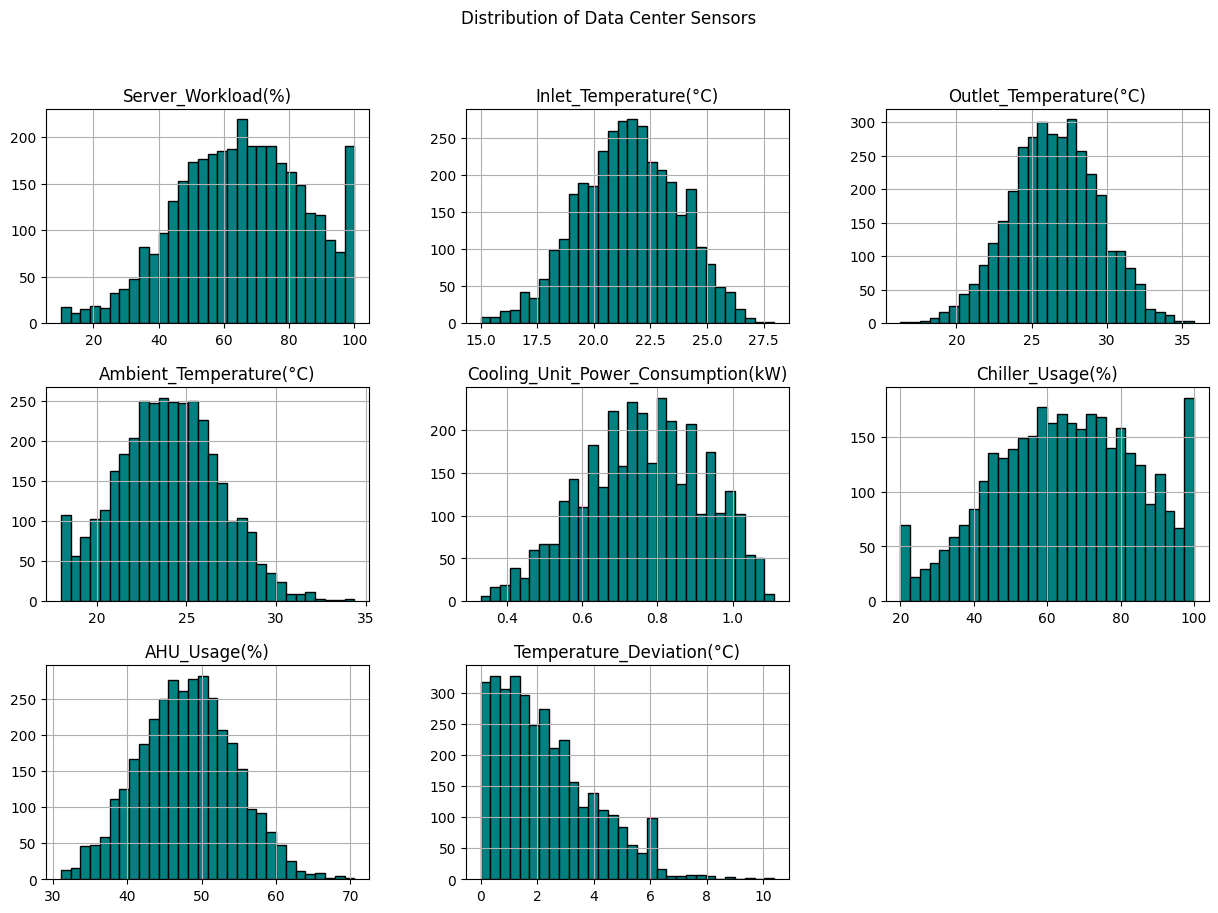

In [7]:
# Plotting Distributions
plt.figure(figsize=(15, 10))
df[features].hist(bins=30, figsize=(15, 10), color='teal', edgecolor='black')
plt.suptitle('Distribution of Data Center Sensors')
plt.savefig('distributions.png')

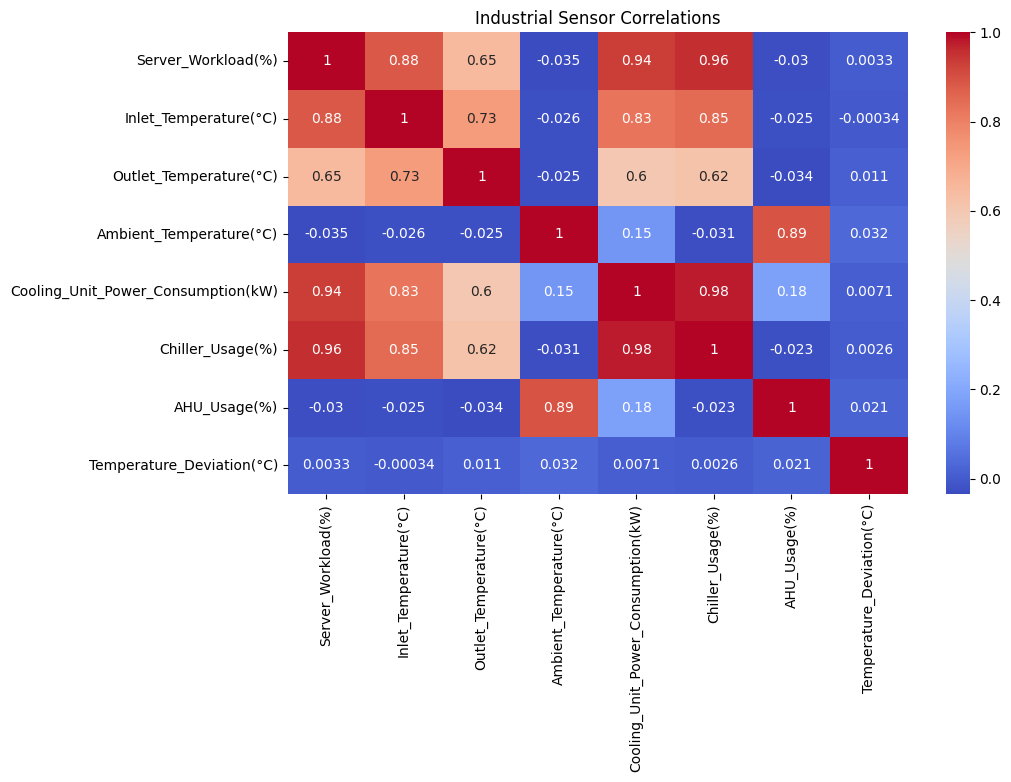

In [8]:
# Plotting Correlations
plt.figure(figsize=(10, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.title("Industrial Sensor Correlations")
plt.savefig('correlation_matrix.png')

### Data Preprocessing

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
# Save scaler for use in the Streamlit App
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [10]:
# Train on 'Normal' data patterns (80/20 split)
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

### Deep Learning Model: Autoencoder

In [11]:
input_dim = X_train.shape[1]
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(4, activation='relu'), # Bottleneck
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

In [12]:
autoencoder.compile(optimizer='adam', loss='mse')
print("Training Digital Twin (Autoencoder)...")
autoencoder.fit(X_train, X_train, epochs=100, batch_size=32, verbose=0, validation_split=0.1)

Training Digital Twin (Autoencoder)...


In [13]:
# Predict on test set
reconstructions = autoencoder.predict(X_test)

# Calculate R2 score across all features
# A high R2 (e.g., > 0.90) means the model has 'learned' the system dynamics
accuracy_r2 = r2_score(X_test, reconstructions)
print(f"Overall Reconstruction Accuracy (R2): {accuracy_r2:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Overall Reconstruction Accuracy (R2): 0.9734


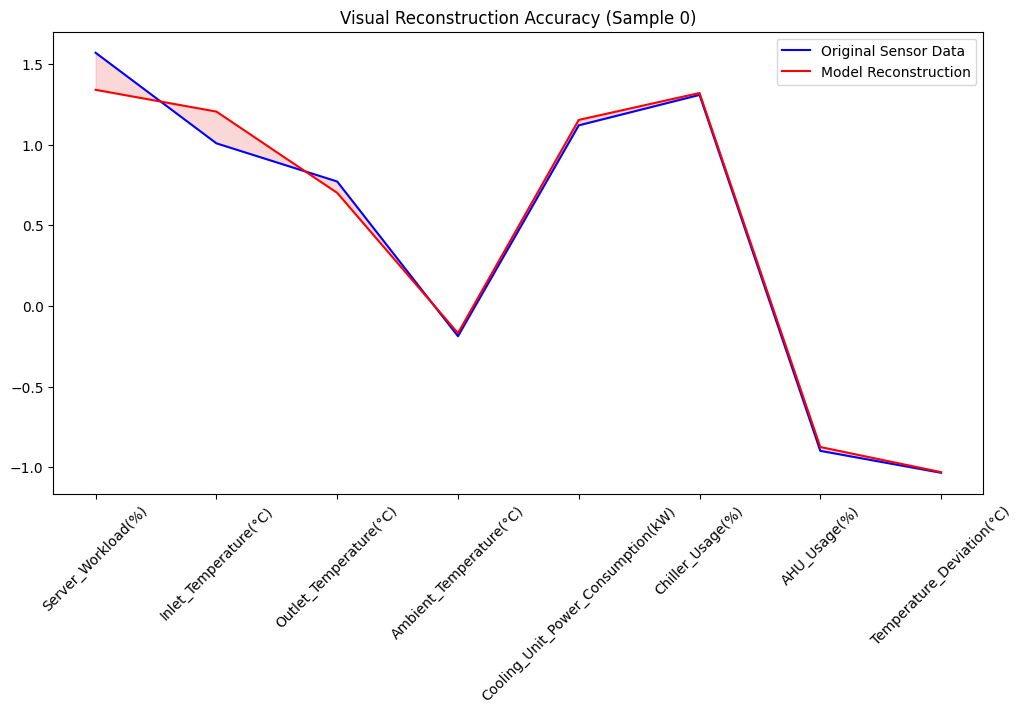

In [14]:
# Plotting the first sample of the test set
sample_idx = 0
plt.figure(figsize=(12, 6))
plt.plot(X_test[sample_idx], 'b', label='Original Sensor Data')
plt.plot(reconstructions[sample_idx], 'r', label='Model Reconstruction')
plt.fill_between(np.arange(len(features)), X_test[sample_idx], reconstructions[sample_idx], color='lightcoral', alpha=0.3)
plt.title("Visual Reconstruction Accuracy (Sample 0)")
plt.xticks(ticks=np.arange(len(features)), labels=features, rotation=45)
plt.legend()
plt.show()

In [15]:
# Save the trained model
autoencoder.save('data_center_ae_model.keras')

### Evaluation and threshhold settings

In [16]:
reconstructions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)
threshold = np.percentile(mse, 98) # Identify the top 2% anomalies
np.save('threshold.npy', threshold)

print(f"Model Training Complete. Threshold set at: {threshold:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Model Training Complete. Threshold set at: 0.0993


### XAI: Interpretability with SHAP

In [17]:
# Define the function SHAP will explain (Reconstruction Error)
def predict_error(data):
    recon = autoencoder.predict(data, verbose=0)
    return np.mean(np.power(data - recon, 2), axis=1)

# Create explainer using a background sample from training data
background = shap.sample(X_train, 100)
explainer = shap.KernelExplainer(predict_error, background)

# Save the explainer object
joblib.dump(explainer, 'shap_explainer.pkl')

['shap_explainer.pkl']

### Comparison with Other Models: One-Class SVM, Isolation Forest, LSTM-Autoencoder

In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import jaccard_score
from scipy.stats import kurtosis
import seaborn as sns

In [19]:
# --- 1. PREPARE TEMPORAL DATA (LSTM Windowing) ---
def create_sequences(values, time_steps=10):
    output = []
    for i in range(len(values) - time_steps):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)

X_train_seq = create_sequences(X_train)
X_test_seq = create_sequences(X_test)

In [20]:
# --- 2. TRAIN ADDITIONAL MODELS ---
print("Training LSTM-Autoencoder, Isolation Forest, and One-Class SVM...")

# LSTM-Autoencoder
lstm_ae = models.Sequential([
    layers.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    layers.LSTM(32, activation='relu', return_sequences=False),
    layers.RepeatVector(X_train_seq.shape[1]),
    layers.LSTM(32, activation='relu', return_sequences=True),
    layers.TimeDistributed(layers.Dense(X_train_seq.shape[2]))
])

Training LSTM-Autoencoder, Isolation Forest, and One-Class SVM...


In [21]:
lstm_ae.compile(optimizer='adam', loss='mse')
lstm_ae.fit(X_train_seq, X_train_seq, epochs=50, batch_size=32, verbose=0)

In [22]:
# Baselines (Contamination set to 2% to match your 98th percentile)
contamination = 0.02
iso_forest = IsolationForest(contamination=contamination, random_state=42).fit(X_test)
oc_svm = OneClassSVM(nu=contamination, kernel="rbf", gamma='auto').fit(X_test)

In [23]:
# --- 3. DERIVE SCORES & ANOMALIES ---
# LSTM Scores
lstm_reconstructions = lstm_ae.predict(X_test_seq)
lstm_mse = np.mean(np.power(X_test_seq - lstm_reconstructions, 2), axis=(1, 2))
lstm_mse_padded = np.pad(lstm_mse, (10, 0), mode='edge') # Align length to X_test

# Baseline Scores (Inverting decision_function so higher = more anomalous)
iso_scores = -iso_forest.decision_function(X_test)
svm_scores = -oc_svm.decision_function(X_test)

# Helper for Normalized Anomaly Strength
def get_strength(scores):
    s = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
    return np.mean(s[s > np.percentile(s, 98)]) / np.mean(s)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


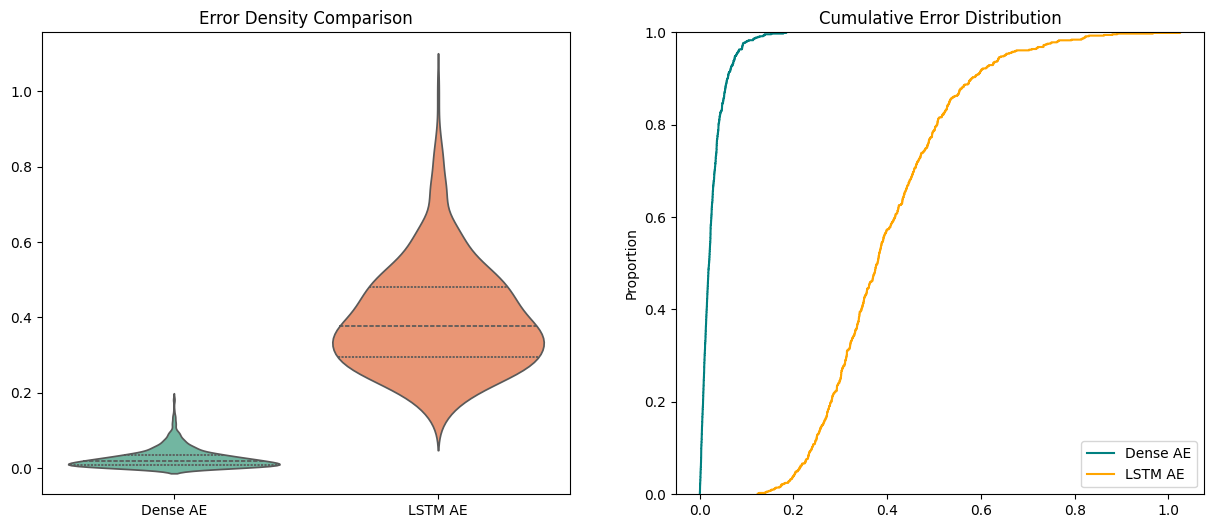

In [24]:
# --- 4. FINAL VISUALIZATION ---
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=pd.DataFrame({'Dense AE': mse, 'LSTM AE': lstm_mse_padded}), palette="Set2", inner="quartile")
plt.title('Error Density Comparison')

plt.subplot(1, 2, 2)
sns.ecdfplot(mse, label='Dense AE', color='teal')
sns.ecdfplot(lstm_mse, label='LSTM AE', color='orange')
plt.title('Cumulative Error Distribution')
plt.legend()
plt.show()

In [25]:
# --- 5. FINAL PERFORMANCE LEADERBOARD ---
# Collecting all metrics into the final requested format
final_comparison = pd.DataFrame({
    "Model": ["Dense Autoencoder", "LSTM-Autoencoder", "Isolation Forest", "One-Class SVM"],
    "Anomaly Strength Index": [get_strength(mse), get_strength(lstm_mse_padded), get_strength(iso_scores), get_strength(svm_scores)],
    "Kurtosis (Separation)": [kurtosis(mse), kurtosis(lstm_mse_padded), kurtosis(iso_scores), kurtosis(svm_scores)],
    "Stability (Std Dev)": [np.std(mse), np.std(lstm_mse_padded), np.std(iso_scores), np.std(svm_scores)],
    "Total Anomalies": [
        (mse > np.percentile(mse, 98)).sum(),
        (lstm_mse > np.percentile(lstm_mse, 98)).sum(),
        (iso_forest.predict(X_test) == -1).sum(),
        (oc_svm.predict(X_test) == -1).sum()
    ],
    "Suitability": ["Real-time App", "Historical Analysis", "Fast Baseline", "Clustered Data"]
})

In [26]:
print("\n--- Final Model Performance Leaderboard ---")
final_comparison.sort_values(by="Anomaly Strength Index", ascending=False)


--- Final Model Performance Leaderboard ---


,Model,Anomaly Strength Index,Kurtosis (Separation),Stability (Std Dev),Total Anomalies,Suitability
0,Dense Autoencoder,4.959014,6.136055,0.025837,14,Real-time App
2,Isolation Forest,3.220480,1.135632,0.047851,14,Fast Baseline
1,LSTM-Autoencoder,2.646960,1.197930,0.140538,14,Historical Analysis
3,One-Class SVM,1.977727,-0.802134,0.107755,20,Clustered Data


### Webapp Config

In [27]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.5 MB/s eta 0:00:00


In [28]:
%%writefile DCapp.py

import streamlit as st
import pandas as pd
import numpy as np
import tensorflow as tf
import joblib
import shap
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
st.set_page_config(page_title="Data Center AI Optimizer", layout="wide")
st.title("🏭 Data Center Anomaly & Prescriptive Optimizer")

# --- 1. LOAD ASSETS ---
@st.cache_resource
def load_assets():
    # Use compile=False to avoid the 'mse' deserialization error
    model = tf.keras.models.load_model('data_center_ae_model.keras')
    scaler = joblib.load('scaler.pkl')
    threshold = np.load('threshold.npy')
    explainer = joblib.load('shap_explainer.pkl')
    return model, scaler, threshold, explainer

# We name the model 'autoencoder' to match the function SHAP is looking for
autoencoder, scaler, threshold, explainer = load_assets()

# --- 2. REDEFINE PREDICTION FUNCTION ---
# This must be defined globally so the SHAP explainer can find it
def predict_error(data):
    # 'autoencoder' here refers to the model loaded above
    recon = autoencoder.predict(data, verbose=0)
    return np.mean(np.power(data - recon, 2), axis=1)

# Manually re-link the explainer to the function in this script
explainer.model.f = predict_error

features = ['Server_Workload(%)', 'Inlet_Temperature(°C)', 'Outlet_Temperature(°C)',
            'Ambient_Temperature(°C)', 'Cooling_Unit_Power_Consumption(kW)',
            'Chiller_Usage(%)', 'AHU_Usage(%)', 'Temperature_Deviation(°C)']

# --- 3. SIDEBAR CONTROLS ---
st.sidebar.header("🕹️ Live Sensor Inputs")

# Define physical ranges based on the dataset statistics
feature_ranges = {
    'Server_Workload(%)': (10.0, 100.0, 65.0),
    'Inlet_Temperature(°C)': (15.0, 28.0, 21.5),
    'Outlet_Temperature(°C)': (16.0, 36.0, 26.5),
    'Ambient_Temperature(°C)': (18.0, 35.0, 24.0),
    'Cooling_Unit_Power_Consumption(kW)': (0.3, 1.2, 0.76), # Crucial Fix
    'Chiller_Usage(%)': (20.0, 100.0, 65.1),
    'AHU_Usage(%)': (30.0, 71.0, 48.0),
    'Temperature_Deviation(°C)': (0.0, 11.0, 2.3)
}

inputs = []
for f in features:
    min_val, max_val, default_val = feature_ranges[f]
    val = st.sidebar.slider(f, min_val, max_val, default_val)
    inputs.append(val)

# --- 4. INFERENCE ---
input_df = pd.DataFrame([inputs], columns=features)
input_scaled = scaler.transform(input_df)

# Calculate current error
reconstruction = autoencoder.predict(input_scaled, verbose=0)
mse = np.mean(np.power(input_scaled - reconstruction, 2))

# --- 5. DASHBOARD DISPLAY ---
col1, col2 = st.columns(2)

with col1:
    st.metric("Anomaly Score (MSE)", f"{mse:.4f}", delta=f"{mse - threshold:.4f}", delta_color="inverse")
    st.write(f"**Anomaly Threshold:** {threshold:.4f}")

    if mse > threshold:
        st.error("⚠️ ANOMALY DETECTED: Cooling Inefficiency")
    else:
        st.success("✅ SYSTEM HEALTHY: Operational within bounds")

with col2:
    st.subheader("🔍 Root Cause Analysis (SHAP)")
    if mse > threshold:
        # SHAP calculation
        with st.spinner("Analyzing root cause..."):
            shap_v = explainer.shap_values(input_scaled)

            fig, ax = plt.subplots()
            # Handle list output from SHAP if necessary
            importance_data = shap_v[0] if isinstance(shap_v, list) else shap_v
            pd.Series(importance_data[0], index=features).plot(kind='barh', ax=ax, color='salmon')
            ax.set_xlabel("Contribution to Anomaly Score")
            st.pyplot(fig)
    else:
        st.write("System behavior is normal. No root cause to analyze.")

# --- 6. PRESCRIPTIVE ANALYSIS ---
st.divider()
st.subheader("💡 Prescriptive Maintenance Actions")

if mse > threshold:
    # Identify feature with highest contribution
    importance_data = shap_v[0] if isinstance(shap_v, list) else shap_v
    top_feature = features[np.argmax(importance_data[0])]

    st.warning(f"**Primary Root Cause identified:** {top_feature}")

    if "Temperature" in top_feature:
        st.info("**Prescription:** High thermal deviation detected. Inspect server rack air filters and check for 'hot aisle' containment leaks.")
    elif "Power" in top_feature or "Usage" in top_feature:
        st.info("**Prescription:** Energy consumption decoupled from load. Perform a mechanical audit of the Chiller compressor and check refrigerant levels.")
    else:
        st.info("**Prescription:** General system anomaly. Verify sensor calibration and check PUE (Power Usage Effectiveness) logs for manual overrides.")
else:
    st.write("Cooling strategy is currently optimized for the existing workload.")

Writing DCapp.py


In [ ]:
!pip install pyngrok
!ngrok config add-authtoken <ADD_YOUR_NGROK_TOKEN_HERE>

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
pub_url = ngrok.connect(8501)
print(pub_url)
!streamlit run DCapp.py

NgrokTunnel: "https://painstakingly-overdescriptive-versie.ngrok-free.dev" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.12.45.131:8501

2026-02-22 10:50:56.550585: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771757456.591887   27762 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771757456.604247   27762 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771757456.633957   27762 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target m